<a href="https://colab.research.google.com/github/codeyson/CPE-313/blob/main/Hands_on_Activity_9_1_Saving_%26_Loading_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-on Activity 9.1: Saving & Loading Models


In [69]:

import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import model_from_json, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import InverseTimeDecay


In [70]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### The dataset is all about Mushroom classification whether it is safe to eat or not.

In [71]:
# Load dataset
mushroom = pd.read_csv('/content/drive/MyDrive/TIP Files/32Sx/CPE 313 (Deep Learning with Python)/Hands-on Activity 9.1 Saving & Loading Models/data/mushrooms.csv')
mushroom.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [72]:
# Separate features and target
X = mushroom.drop('class', axis=1)
y = mushroom['class']

# Encode target variable
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# one-hot encoding
X = pd.get_dummies(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (5686, 117)
X_test shape: (2438, 117)


In [73]:
def build_model(optimizer='adam'):
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),   # visible/input layer
        layers.Dropout(0.2, name='dropout_visible'),  # Dropout on visible layer
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3, name='dropout_hidden_1'), # Dropout on hidden layer
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3, name='dropout_hidden_2'), # Dropout on hidden layer
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_visible (Dropout)       │ (None, 117)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 128)            │        15,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_hidden_1 (Dropout)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_hidden_2 (Dropout)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,425 (91.50 KB)

 Trainable params: 23,425 (91.50 KB)

 Non-trainable params: 0 (0.00 B)

## A. Train the base model and visualize training history

In [74]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9164 - loss: 0.2187 - val_accuracy: 0.9974 - val_loss: 0.0209
Epoch 2/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9822 - loss: 0.0503 - val_accuracy: 1.0000 - val_loss: 0.0056
Epoch 3/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9877 - loss: 0.0330 - val_accuracy: 0.9982 - val_loss: 0.0038
Epoch 4/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9916 - loss: 0.0245 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 5/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9932 - loss: 0.0177 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 6/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9952 - loss: 0.0163 - val_accuracy: 1.0000 - val_loss: 9.1434e-04
Epoch 7/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9945 - loss: 0.0145 - val_accuracy: 1.0000 - val_loss: 9.3994e-04
Epoch 8/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9949 - loss: 0.0119 - val_accu

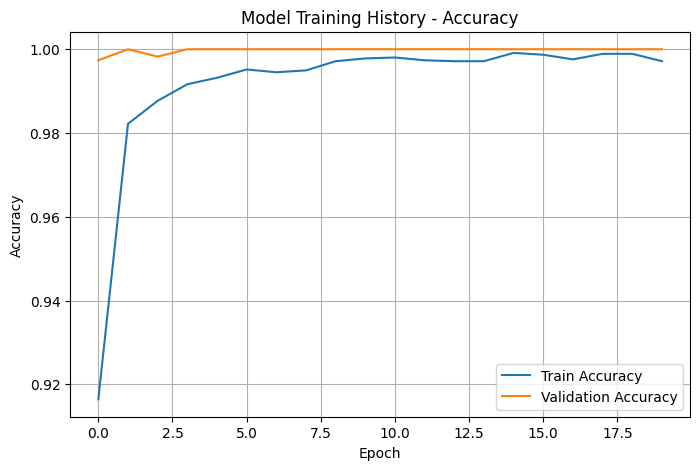

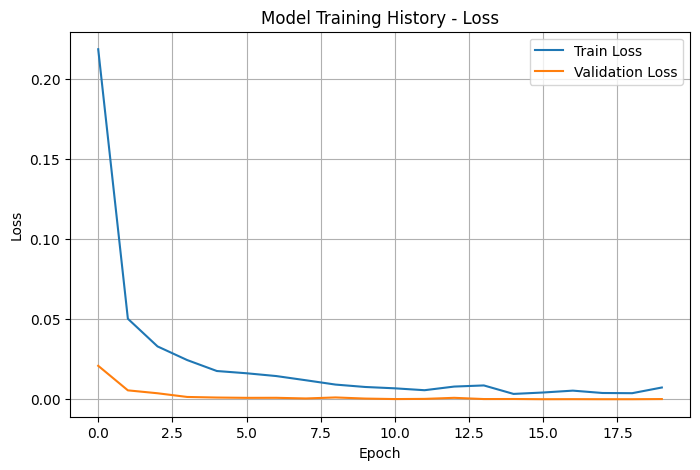

In [75]:
# Visualizationn
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Training History - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [76]:
# Evaluate base model
predictions = model.predict(X_test)
y_pred = (predictions > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

accuracy = accuracy_score(y_test, y_pred)
print(f'\nAccuracy Score: {accuracy:.4f}')

f1 = f1_score(y_test, y_pred)
print(f'F1 Score: {f1:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix:
[[1263    0]
 [   0 1175]]

Accuracy Score: 1.0000
F1 Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1263
           1       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



## B. Save a model in H5 format and load it

In [77]:
# Save model in H5 format
model.save('mushroom_model.h5')
print("Saved model as mushroom_model.h5")

# Load saved H5 model
loaded_h5_model = load_model('mushroom_model.h5')
print("Loaded model from H5 file")

Saved model as mushroom_model.h5


Loaded model from H5 file


## C. Save model architecture in JSON and load it

In [78]:
# Save architecture to JSON
model_json = model.to_json()
with open('mushroom_model.json', 'w') as json_file:
    json_file.write(model_json)

# Load architecture from JSON
with open('mushroom_model.json', 'r') as json_file:
    loaded_json = json_file.read()

loaded_json_model = model_from_json(loaded_json)
loaded_json_model.set_weights(model.get_weights())
loaded_json_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Saved and loaded model architecture using JSON")

Saved and loaded model architecture using JSON


## D. Save model configuration in YAML and load it


In [79]:
# Save model config as YAML
model_config = model.get_config()
with open('mushroom_model.yaml', 'w') as yaml_file:
    yaml.safe_dump(model_config, yaml_file)

# Load model config from YAML
with open('mushroom_model.yaml', 'r') as yaml_file:
    loaded_yaml_config = yaml.safe_load(yaml_file)

loaded_yaml_model = keras.Sequential.from_config(loaded_yaml_config)
loaded_yaml_model.set_weights(model.get_weights())
loaded_yaml_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Saved and loaded model configuration using YAML")

Saved and loaded model configuration using YAML


## E. Checkpoint Neural Network Model Improvements and Best Model Only

In [ ]:
# saves after every epoch
checkpoint_all = ModelCheckpoint(
    'checkpoint_every_epoch.keras',
    monitor='val_accuracy',
    save_best_only=False,
    verbose=1
)

# saves only the best model
checkpoint_best = ModelCheckpoint(
    'checkpoint_best_only.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

checkpoint_model = build_model()
history_checkpoint = checkpoint_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[checkpoint_all, checkpoint_best],
    verbose=1
)

Epoch 1/10
140/143 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7960 - loss: 0.4165
Epoch 1: saving model to checkpoint_every_epoch.keras

Epoch 1: finished saving model to checkpoint_every_epoch.keras

Epoch 1: val_accuracy improved from None to 0.99736, saving model to checkpoint_best_only.keras

Epoch 1: finished saving model to checkpoint_best_only.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8975 - loss: 0.2413 - val_accuracy: 0.9974 - val_loss: 0.0204
Epoch 2/10


## F. Time-based learning rate schedule

In [ ]:
# Time-based learning rate schedule using InverseTimeDecay
time_based_lr = InverseTimeDecay(
    initial_learning_rate=0.01,
    decay_steps=100,
    decay_rate=0.5,
    staircase=False
)

time_model = build_model(optimizer=Adam(learning_rate=time_based_lr))
history_time = time_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

print("Applied a time-based learning rate schedule")

## G. Drop-based learning rate schedule

In [ ]:
# Drop-based learning rate schedule
def drop_based_schedule(epoch, lr):
    if epoch > 0 and epoch % 5 == 0:
        return lr * 0.5
    return lr

drop_lr_callback = LearningRateScheduler(drop_based_schedule, verbose=1)

drop_model = build_model(optimizer=Adam(learning_rate=0.01))
history_drop = drop_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[drop_lr_callback],
    verbose=1
)

print("Applied a drop-based learning rate schedule")

## H. Load a saved neural network model and test it

In [ ]:
reloaded_model = load_model('checkpoint_best_only.keras')
loss, acc = reloaded_model.evaluate(X_test, y_test, verbose=0)
print(f"Reloaded best checkpoint accuracy: {acc:.4f}")

### Conclusion

In this activity, I learned how to build and improve a classification model using neural networks. I learned how to save the model in different formats like H5, JSON, and YAML, and also how to load them again. I also learned how to use checkpoint to save the model during training and keep the best version. I understand how dropout helps reduce overfitting by removing some neurons in the visible and hidden layers. I also learned how to change the learning rate using time-based and drop-based methods. Overall, this activity helped me understand better how to train, save, and manage a neural network model.